/Users/halders2/.local/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Double-pendulum benchmark data check
------------------------------------
Loaded file: double_pendulum_chaotic_data.csv
Data shape: (28, 2000)
Expected rows: 28
Number of sampled trajectories: 2000
Number of saved timepoints per trajectory: 7
Sampled post-transient times: [10. 15. 20. 25. 30. 35. 40.]
Direct transition interval Delta t: 5.0000
Finite values only: True

Displayed saved sample summary
------------------------------
Sample index: 0
theta1 range: -1.7739 to 1.7138
theta2 range: -18.7886 to 6.5467
omega1 range: -5.2657 to 5.5224
omega2 range: -9.8929 to 4.5250

Dense visualization trajectory summary
--------------------------------------
post-transient theta1 range: -2.0949 to 1.7033
post-transient theta2 range: -34.4007 to 8.6150
post-transient omega1 range: -6.4380 to 7.4222
post-transient omega2 range: -10.8464 to 9.6643


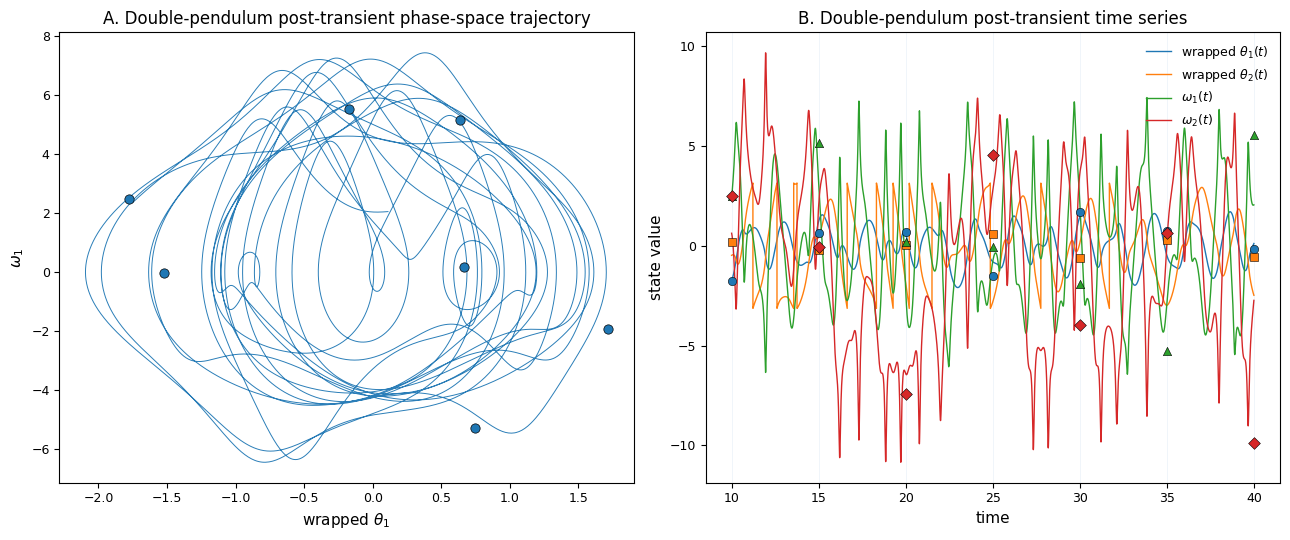


Saved PDF: supplementary_double_pendulum_benchmark_trajectory.pdf
Saved JPEG: supplementary_double_pendulum_benchmark_trajectory.jpeg
Status: Figure is ready for Supplementary Materials.


In [1]:
# ============================================================
# Supplementary double-pendulum benchmark figure
# Uses saved DynML sparse benchmark data + dense representative
# trajectory for visualization.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from pathlib import Path

# ------------------------
# Files
# ------------------------
csv_file = Path("double_pendulum_chaotic_data.csv")
output_pdf = "supplementary_double_pendulum_benchmark_trajectory.pdf"
output_jpeg = "supplementary_double_pendulum_benchmark_trajectory.jpeg"

# ------------------------
# Double-pendulum parameters
# ------------------------
m1 = 1.0
m2 = 1.0
L1 = 1.0
L2 = 1.0
g = 9.81

base_x0 = np.array([np.pi / 2, np.pi / 2 + 0.1, 0.0, 0.0])

T = 7
t_total = 40
transient_time = 10
sample_times = np.linspace(transient_time, t_total, T)

# ------------------------
# Helper: wrap angles to [-pi, pi]
# ------------------------
def wrap_angle(theta):
    return (theta + np.pi) % (2 * np.pi) - np.pi

# ------------------------
# Load saved sparse benchmark data
# ------------------------
if not csv_file.exists():
    raise FileNotFoundError(f"Could not find {csv_file}")

df = pd.read_csv(csv_file)
data = df.values

expected_rows = 4 * T
if data.shape[0] != expected_rows:
    raise ValueError(f"Expected {expected_rows} rows, but found {data.shape[0]} rows.")

if not np.all(np.isfinite(data)):
    raise ValueError("Saved double-pendulum data contain NaN or infinite values.")

num_samples = data.shape[1]

# Rows are theta1_1..theta1_7, theta2_1..theta2_7,
# omega1_1..omega1_7, omega2_1..omega2_7
theta1_sparse_all = data[0:T, :]
theta2_sparse_all = data[T:2*T, :]
omega1_sparse_all = data[2*T:3*T, :]
omega2_sparse_all = data[3*T:4*T, :]

# Choose one saved trajectory/sample to display
sample_index = 0
theta1_sparse = theta1_sparse_all[:, sample_index]
theta2_sparse = theta2_sparse_all[:, sample_index]
omega1_sparse = omega1_sparse_all[:, sample_index]
omega2_sparse = omega2_sparse_all[:, sample_index]

theta1_sparse_wrapped = wrap_angle(theta1_sparse)
theta2_sparse_wrapped = wrap_angle(theta2_sparse)

# ------------------------
# Define double-pendulum dynamics
# ------------------------
def double_pendulum(t, X):
    theta1, theta2, w1, w2 = X

    delta = theta2 - theta1

    den1 = (m1 + m2) * L1 - m2 * L1 * np.cos(delta) ** 2
    den2 = (L2 / L1) * den1

    dtheta1 = w1
    dtheta2 = w2

    dw1 = (
        m2 * L1 * w1**2 * np.sin(delta) * np.cos(delta)
        + m2 * g * np.sin(theta2) * np.cos(delta)
        + m2 * L2 * w2**2 * np.sin(delta)
        - (m1 + m2) * g * np.sin(theta1)
    ) / den1

    dw2 = (
        -m2 * L2 * w2**2 * np.sin(delta) * np.cos(delta)
        + (m1 + m2)
        * (
            g * np.sin(theta1) * np.cos(delta)
            - L1 * w1**2 * np.sin(delta)
            - g * np.sin(theta2)
        )
    ) / den2

    return [dtheta1, dtheta2, dw1, dw2]

# ------------------------
# Generate dense representative trajectory for visualization
# ------------------------
t_dense = np.linspace(0, t_total, 20000)

sol_dense = solve_ivp(
    double_pendulum,
    (0, t_total),
    base_x0,
    t_eval=t_dense,
    rtol=1e-9,
    atol=1e-12
)

if not sol_dense.success:
    raise RuntimeError("Dense double-pendulum integration failed: " + sol_dense.message)

mask = t_dense >= transient_time
t_plot = t_dense[mask]

theta1_plot = sol_dense.y[0, mask]
theta2_plot = sol_dense.y[1, mask]
omega1_plot = sol_dense.y[2, mask]
omega2_plot = sol_dense.y[3, mask]

theta1_plot_wrapped = wrap_angle(theta1_plot)
theta2_plot_wrapped = wrap_angle(theta2_plot)

# ------------------------
# Basic data checks
# ------------------------
print("Double-pendulum benchmark data check")
print("------------------------------------")
print(f"Loaded file: {csv_file}")
print(f"Data shape: {data.shape}")
print(f"Expected rows: {expected_rows}")
print(f"Number of sampled trajectories: {num_samples}")
print(f"Number of saved timepoints per trajectory: {T}")
print(f"Sampled post-transient times: {sample_times}")
print(f"Direct transition interval Delta t: {(t_total - transient_time) / (T - 1):.4f}")
print(f"Finite values only: {np.all(np.isfinite(data))}")
print()
print("Displayed saved sample summary")
print("------------------------------")
print(f"Sample index: {sample_index}")
print(f"theta1 range: {theta1_sparse.min():.4f} to {theta1_sparse.max():.4f}")
print(f"theta2 range: {theta2_sparse.min():.4f} to {theta2_sparse.max():.4f}")
print(f"omega1 range: {omega1_sparse.min():.4f} to {omega1_sparse.max():.4f}")
print(f"omega2 range: {omega2_sparse.min():.4f} to {omega2_sparse.max():.4f}")
print()
print("Dense visualization trajectory summary")
print("--------------------------------------")
print(f"post-transient theta1 range: {theta1_plot.min():.4f} to {theta1_plot.max():.4f}")
print(f"post-transient theta2 range: {theta2_plot.min():.4f} to {theta2_plot.max():.4f}")
print(f"post-transient omega1 range: {omega1_plot.min():.4f} to {omega1_plot.max():.4f}")
print(f"post-transient omega2 range: {omega2_plot.min():.4f} to {omega2_plot.max():.4f}")

# ------------------------
# Plot
# ------------------------
fig = plt.figure(figsize=(13, 5.5))

# A. Phase-space trajectory
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(theta1_plot_wrapped, omega1_plot, linewidth=0.7, alpha=0.95)
ax1.scatter(
    theta1_sparse_wrapped,
    omega1_sparse,
    s=45,
    marker="o",
    edgecolor="black",
    linewidth=0.5,
    zorder=5
)
ax1.set_title(r"A. Double-pendulum post-transient phase-space trajectory", fontsize=12)
ax1.set_xlabel(r"wrapped $\theta_1$", fontsize=11)
ax1.set_ylabel(r"$\omega_1$", fontsize=11)
ax1.tick_params(labelsize=9)

# B. Time series
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(t_plot, theta1_plot_wrapped, linewidth=1.0, label=r"wrapped $\theta_1(t)$")
ax2.plot(t_plot, theta2_plot_wrapped, linewidth=1.0, label=r"wrapped $\theta_2(t)$")
ax2.plot(t_plot, omega1_plot, linewidth=1.0, label=r"$\omega_1(t)$")
ax2.plot(t_plot, omega2_plot, linewidth=1.0, label=r"$\omega_2(t)$")

# Show all seven sampled points for all four coordinates
ax2.scatter(sample_times, theta1_sparse_wrapped, s=36, marker="o", edgecolor="black", linewidth=0.4, zorder=5)
ax2.scatter(sample_times, theta2_sparse_wrapped, s=36, marker="s", edgecolor="black", linewidth=0.4, zorder=5)
ax2.scatter(sample_times, omega1_sparse, s=36, marker="^", edgecolor="black", linewidth=0.4, zorder=5)
ax2.scatter(sample_times, omega2_sparse, s=36, marker="D", edgecolor="black", linewidth=0.4, zorder=5)

# Very faint vertical lines show sparse sampling times
for t in sample_times:
    ax2.axvline(t, linewidth=0.4, alpha=0.12)

ax2.set_title("B. Double-pendulum post-transient time series", fontsize=12)
ax2.set_xlabel("time", fontsize=11)
ax2.set_ylabel("state value", fontsize=11)
ax2.legend(frameon=False, fontsize=9, loc="upper right")
ax2.tick_params(labelsize=9)

plt.tight_layout()

plt.savefig(output_pdf, bbox_inches="tight")
plt.savefig(output_jpeg, dpi=600, bbox_inches="tight")
plt.show()

print()
print(f"Saved PDF: {output_pdf}")
print(f"Saved JPEG: {output_jpeg}")
print("Status: Figure is ready for Supplementary Materials.")